In [ ]:
import os
import numpy as np
from tqdm import tqdm  # 진행바 표시 (설치: pip install tqdm)
from PIL import Image
import csv

# 1. 파일 및 저장 경로 설정
npz_path = r"C:\Users\daeun\Desktop\학부연구생 과제\20250204\QG_jets_1.npz"
output_dir = r"C:\Users\daeun\Desktop\학부연구생 과제\20250204\dataset(200000)"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 2. npz 파일 로드 (키: X, y)
data = np.load(npz_path)
X = data['X']   # shape: (100000, M, 4), M: 입자 개수, (pt, eta, phi, pdgid)
y = data['y']   # shape: (100000,)

# 3. 전처리할 제트 수 (여기서는 100000개만)
num_images = 100000
print(f"전체 {X.shape[0]}개 중 앞의 {num_images}개 제트를 전처리합니다.")

# 전처리 파라미터
R = 0.4                # (η, φ) 범위: [-R, R]
img_size = 33          # 33×33 픽셀 이미지
pixel_extent = 2 * R   # 전체 범위: 0.8
pixel_size = pixel_extent / img_size  # 한 픽셀 당 길이

# 4. 결과 이미지를 저장할 배열 (shape: (num_images, 33, 33, 3))
jet_images = np.zeros((num_images, img_size, img_size, 3), dtype=np.float32)

# 하전 입자 판별 함수, 하전 입자면 true 반환?
def is_charged(pdgid):
    """
    pdgid 값을 기반으로 하전 입자 여부를 판단합니다.
    (여기서는 흔히 사용되는 하전 입자 PDG 코드: 211, 321, 2212와 그 음수값)
    """
    try:
        pdg = int(round(pdgid))
    except:
        pdg = 0
    charged_ids = {211, -211, 321, -321, 2212, -2212}
    return pdg in charged_ids

# 5. 각 제트에 대해 이미지 생성
for i in tqdm(range(num_images), desc="Processing jets"):
    jet = X[i]  # shape: (M, 4) → [pt, rapidity, azimuth, pdgid]
    pts    = jet[:, 0]
    etas   = jet[:, 1]
    phis   = jet[:, 2]
    pdgids = jet[:, 3]

    # pT > 0 인 유효 입자만 사용 (패딩된 입자 무시)
    valid = pts > 0
    if not np.any(valid):
        continue  # 모든 입자가 0이면 건너뛰기
    pts_valid   = pts[valid]
    etas_valid  = etas[valid]
    phis_valid  = phis[valid]
    pdgids_valid= pdgids[valid]

    # **중심 정렬 (Centering):** 모든 유효 입자에 대해 pT 가중 중심 계산
    sum_pt = np.sum(pts_valid)
    center_eta = np.sum(pts_valid * etas_valid) / sum_pt
    center_phi = np.sum(pts_valid * phis_valid) / sum_pt

    # 모든 입자의 (η, φ)를 중심 (0,0)으로 이동
    etas_shifted = etas - center_eta
    phis_shifted = phis - center_phi

    # 제트 이미지 (RGB, 33×33) 초기화
    image = np.zeros((img_size, img_size, 3), dtype=np.float32)

    # 각 입자에 대해 (η, φ) 좌표에 해당하는 픽셀에 값을 누적
    for pt, eta_val, phi_val, pdgid in zip(pts, etas_shifted, phis_shifted, pdgids):
        if pt <= 0:
            continue
        # cropping: (η, φ)가 [-R, R] 범위 내에 있어야 함
        if (eta_val < -R) or (eta_val > R) or (phi_val < -R) or (phi_val > R):
            continue
        # 픽셀 인덱스 계산 (η, φ = (-R,-R) → (0,0), (R,R) → (img_size-1, img_size-1))
        ix = int((eta_val + R) / pixel_size)
        iy = int((phi_val + R) / pixel_size)
        ix = np.clip(ix, 0, img_size - 1)
        iy = np.clip(iy, 0, img_size - 1)

        # 채널별 매핑:
        if is_charged(pdgid):
            # Red 채널: 하전 입자의 pT 누적
            image[ix, iy, 0] += pt
            # Blue 채널: 하전 입자 개수 (Multiplicity) 누적
            image[ix, iy, 2] += 1
        else:
            # Green 채널: 중성 입자의 pT 누적
            image[ix, iy, 1] += pt

    # **정규화 (Normalization):** 각 채널별로 전체 픽셀 합이 1이 되도록 함
    for ch in range(3):
        ch_sum = image[:, :, ch].sum()
        if ch_sum > 0:
            image[:, :, ch] /= ch_sum

    jet_images[i] = image

# 6. 전체 10개 제트에 대해 픽셀별, 채널별 평균과 표준편차 계산 (표준화에 사용)
mean_image = np.mean(jet_images, axis=0)  # shape: (33, 33, 3)
std_image  = np.std(jet_images, axis=0)   # shape: (33, 33, 3)
print("채널별 mean과 std 이미지 계산 완료.")

# 7. 각 제트 이미지에 대해 표준화 수행:
#    I_ij(k) -> (I_ij(k) - μ_ij(k)) / (σ_ij(k) + 1e-5)
jet_images_std = (jet_images - mean_image) / (std_image + 1e-5)

# 8. 학습/시각화용으로 PNG 파일로 저장하기 위해 [0,1] 범위로 min–max scaling 후, 0~255의 uint8로 변환
for i in range(num_images):
    img = jet_images_std[i]
    # 전체 이미지의 최소값을 0으로 shift
    img = img - img.min()
    # 최대값이 0보다 크면 [0,1]로 스케일링
    if img.max() > 0:
        img = img / img.max()
    # uint8 변환
    img_uint8 = (img * 255).astype(np.uint8)

    # 파일 이름 예: jet_000000.png, jet_000001.png, ...
    filename = os.path.join(output_dir, f"jet_{100000+i:06d}.png")
    Image.fromarray(img_uint8).save(filename)

# 9. 제트에 대한 레이블 파일 생성 (CSV 파일: 파일명과 레이블: gluon=0, quark=1)
labels_list = []
for i in range(num_images):
    fname = f"jet_{i:06d}.png"
    label = int(y[i])
    labels_list.append((fname, label))

labels_csv_path = os.path.join(output_dir, "labels2.csv")
with open(labels_csv_path, mode='w', newline='') as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["filename", "label"])
    writer.writerows(labels_list)

print("10개의 RGB 이미지와 레이블 CSV 파일(labels.csv)이 생성되었습니다.")

전체 100000개 중 앞의 100000개 제트를 전처리합니다.


Processing jets: 100%|████████████████████████████████████████████████████████| 100000/100000 [04:01<00:00, 414.30it/s]


채널별 mean과 std 이미지 계산 완료.
10개의 RGB 이미지와 레이블 CSV 파일(labels.csv)이 생성되었습니다.


In [ ]:
# 이미지 전체(100000개) 생성.
import os
import numpy as np
from tqdm import tqdm  # 진행바 표시 (설치: pip install tqdm)
from PIL import Image
import csv

# 1. 파일 및 저장 경로 설정
npz_path = r"C:\Users\daeun\Desktop\학부연구생 과제\20250204\QG_jets.npz"
output_dir = r"C:\Users\daeun\Desktop\학부연구생 과제\20250204\dataset(100000)"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 2. npz 파일 로드 (키: X, y)
data = np.load(npz_path)
X = data['X']   # shape: (100000, M, 4), M: 입자 개수, (pt, eta, phi, pdgid)
y = data['y']   # shape: (100000,)

# 3. 전처리할 제트 수 (여기서는 100000개만)
num_images = 100000
print(f"전체 {X.shape[0]}개 중 앞의 {num_images}개 제트를 전처리합니다.")

# 전처리 파라미터
R = 0.4                # (η, φ) 범위: [-R, R]
img_size = 33          # 33×33 픽셀 이미지
pixel_extent = 2 * R   # 전체 범위: 0.8
pixel_size = pixel_extent / img_size  # 한 픽셀 당 길이

# 4. 결과 이미지를 저장할 배열 (shape: (num_images, 33, 33, 3))
jet_images = np.zeros((num_images, img_size, img_size, 3), dtype=np.float32)

# 하전 입자 판별 함수, 하전 입자면 true 반환?
def is_charged(pdgid):
    """
    pdgid 값을 기반으로 하전 입자 여부를 판단합니다.
    (여기서는 흔히 사용되는 하전 입자 PDG 코드: 211, 321, 2212와 그 음수값)
    """
    try:
        pdg = int(round(pdgid))
    except:
        pdg = 0
    charged_ids = {211, -211, 321, -321, 2212, -2212}
    return pdg in charged_ids

# 5. 각 제트에 대해 이미지 생성
for i in tqdm(range(num_images), desc="Processing jets"):
    jet = X[i]  # shape: (M, 4) → [pt, rapidity, azimuth, pdgid]
    pts    = jet[:, 0]
    etas   = jet[:, 1]
    phis   = jet[:, 2]
    pdgids = jet[:, 3]

    # pT > 0 인 유효 입자만 사용 (패딩된 입자 무시)
    valid = pts > 0
    if not np.any(valid):
        continue  # 모든 입자가 0이면 건너뛰기
    pts_valid   = pts[valid]
    etas_valid  = etas[valid]
    phis_valid  = phis[valid]
    pdgids_valid= pdgids[valid]

    # **중심 정렬 (Centering):** 모든 유효 입자에 대해 pT 가중 중심 계산?????
    sum_pt = np.sum(pts_valid)
    center_eta = np.sum(pts_valid * etas_valid) / sum_pt
    center_phi = np.sum(pts_valid * phis_valid) / sum_pt

    # 모든 입자의 (η, φ)를 중심 (0,0)으로 이동
    etas_shifted = etas - center_eta
    phis_shifted = phis - center_phi

    # 제트 이미지 (RGB, 33×33) 초기화
    image = np.zeros((img_size, img_size, 3), dtype=np.float32)

    # 각 입자에 대해 (η, φ) 좌표에 해당하는 픽셀에 값을 누적
    for pt, eta_val, phi_val, pdgid in zip(pts, etas_shifted, phis_shifted, pdgids):
        if pt <= 0:
            continue
        # cropping: (η, φ)가 [-R, R] 범위 내에 있어야 함
        if (eta_val < -R) or (eta_val > R) or (phi_val < -R) or (phi_val > R):
            continue
        # 픽셀 인덱스 계산 (η, φ = (-R,-R) → (0,0), (R,R) → (img_size-1, img_size-1))
        ix = int((eta_val + R) / pixel_size)
        iy = int((phi_val + R) / pixel_size)
        ix = np.clip(ix, 0, img_size - 1)
        iy = np.clip(iy, 0, img_size - 1)

        # 채널별 매핑:
        if is_charged(pdgid):
            # Red 채널: 하전 입자의 pT 누적
            image[ix, iy, 0] += pt
            # Blue 채널: 하전 입자 개수 (Multiplicity) 누적
            image[ix, iy, 2] += 1
        else:
            # Green 채널: 중성 입자의 pT 누적
            image[ix, iy, 1] += pt

    # **정규화 (Normalization):** 각 채널별로 전체 픽셀 합이 1이 되도록 함
    for ch in range(3):
        ch_sum = image[:, :, ch].sum()
        if ch_sum > 0:
            image[:, :, ch] /= ch_sum

    jet_images[i] = image

# 6. 전체 10개 제트에 대해 픽셀별, 채널별 평균과 표준편차 계산 (표준화에 사용)
mean_image = np.mean(jet_images, axis=0)  # shape: (33, 33, 3)
std_image  = np.std(jet_images, axis=0)   # shape: (33, 33, 3)
print("채널별 mean과 std 이미지 계산 완료.")

# 7. 각 제트 이미지에 대해 표준화 수행:
#    I_ij(k) -> (I_ij(k) - μ_ij(k)) / (σ_ij(k) + 1e-5)
jet_images_std = (jet_images - mean_image) / (std_image + 1e-5)

# 8. 학습/시각화용으로 PNG 파일로 저장하기 위해 [0,1] 범위로 min–max scaling 후, 0~255의 uint8로 변환
for i in range(num_images):
    img = jet_images_std[i]
    # 전체 이미지의 최소값을 0으로 shift
    img = img - img.min()
    # 최대값이 0보다 크면 [0,1]로 스케일링
    if img.max() > 0:
        img = img / img.max()
    # uint8 변환
    img_uint8 = (img * 255).astype(np.uint8)

    # 파일 이름 예: jet_000000.png, jet_000001.png, ...
    filename = os.path.join(output_dir, f"jet_{i:06d}.png")
    Image.fromarray(img_uint8).save(filename)

# 9. 제트에 대한 레이블 파일 생성 (CSV 파일: 파일명과 레이블: gluon=0, quark=1)
labels_list = []
for i in range(num_images):
    fname = f"jet_{i:06d}.png"
    label = int(y[i])
    labels_list.append((fname, label))

labels_csv_path = os.path.join(output_dir, "labels.csv")
with open(labels_csv_path, mode='w', newline='') as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["filename", "label"])
    writer.writerows(labels_list)

print("10개의 RGB 이미지와 레이블 CSV 파일(labels.csv)이 생성되었습니다.")

전체 100000개 중 앞의 100000개 제트를 전처리합니다.


Processing jets: 100%|████████████████████████████████████████████████████████| 100000/100000 [07:34<00:00, 219.91it/s]


채널별 mean과 std 이미지 계산 완료.
10개의 RGB 이미지와 레이블 CSV 파일(labels.csv)이 생성되었습니다.


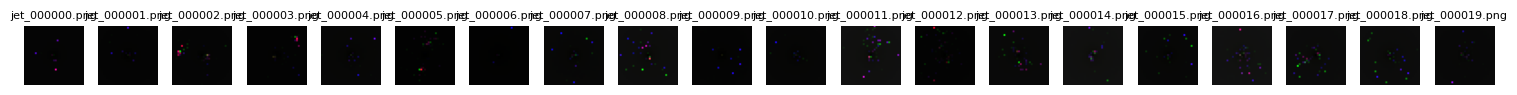

In [ ]:
# 10개만 이미지 출력해봄.

import os
import matplotlib.pyplot as plt
from PIL import Image

# 이미지 파일들이 저장된 디렉터리 경로
dataset_dir = r"C:\Users\daeun\Desktop\학부연구생 과제\20250204\dataset"

# 디렉터리 내의 PNG 파일들을 리스트로 가져오기 (정렬하여 순서를 맞춤)
image_files = sorted([f for f in os.listdir(dataset_dir) if f.endswith(".png")])

# 10개의 이미지 파일 선택 (npz 전처리 코드에서 저장한 순서와 동일하다고 가정)
num_images = 20
selected_images = image_files[:num_images]

# 10개의 이미지를 출력 (1행 10열 서브플롯)
plt.figure(figsize=(15, 3))
for i, image_file in enumerate(selected_images):
    img_path = os.path.join(dataset_dir, image_file)
    img = Image.open(img_path)
    plt.subplot(1, num_images, i + 1)
    plt.imshow(img)
    plt.title(image_file, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# vit-tiny(100000)
# 79.62%
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm  # pip install timm

# -----------------------------
# 1. 사용자 정의 Dataset 클래스
# -----------------------------
class JetHeatmapDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (str): 이미지 파일명과 레이블이 기록된 CSV 파일 경로.
            root_dir (str): 이미지 파일들이 저장된 디렉터리 경로.
            transform (callable, optional): 이미지에 적용할 변환.
        """
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # CSV의 첫 번째 컬럼: 파일명, 두 번째 컬럼: 레이블
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# -----------------------------
# 2. 메인 코드 (timm의 ViT 모델 파인튜닝 - 후반 4개 블록만 학습)
# -----------------------------
if __name__ == '__main__':
    # GPU 사용 여부 확인
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # 데이터셋 디렉터리 및 CSV 파일 경로 설정
    dataset_dir = r"C:\Users\daeun\Desktop\학부연구생 과제\20250204\dataset(100000)"
    labels_csv_path = os.path.join(dataset_dir, "labels.csv")

    # CSV 파일 로드 및 train/validation 분할 (클래스 비율 유지)
    df = pd.read_csv(labels_csv_path)
    print("CSV preview:")
    print(df.head())
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    # 분할된 데이터를 임시 CSV 파일로 저장 (Dataset 클래스에서 사용)
    train_csv = os.path.join(dataset_dir, "train_labels.csv")
    val_csv = os.path.join(dataset_dir, "val_labels.csv")
    train_df.to_csv(train_csv, index=False)
    val_df.to_csv(val_csv, index=False)

    # -----------------------------
    # 3. 데이터 변환 및 DataLoader 구성
    # -----------------------------
    # vit_tiny_patch16_224 모델의 기본 입력 크기인 224×224에 맞춰 전처리합니다.
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        # transforms.RandomHorizontalFlip(),  # 데이터 증강 옵션 (필요 시 사용)
        # transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        # 필요시 transforms.Normalize(mean, std) 추가
    ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    # Dataset 객체 생성
    train_dataset = JetHeatmapDataset(csv_file=train_csv, root_dir=dataset_dir, transform=train_transform)
    val_dataset = JetHeatmapDataset(csv_file=val_csv, root_dir=dataset_dir, transform=val_transform)

    # DataLoader 생성 (배치 크기: 128, Windows 환경에서는 num_workers=0)
    batch_size = 64
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # -----------------------------
    # 4. timm 모델 불러오기 및 파인튜닝 설정 (후반 4개 블록만 학습)
    # -----------------------------
    # 'vit_tiny_patch16_224' 모델을 사전 학습된 가중치로 불러오고,
    # 분류 헤드를 우리의 클래스 수(여기서는 2)로 맞춥니다.
    model_name = 'vit_tiny_patch16_224'
    model = timm.create_model(model_name, pretrained=True, num_classes=2)

    # 전체 Transformer 블록 중, 마지막 4개 블록만 학습시키고 나머지는 동결합니다.
    total_blocks = len(model.blocks)
    num_trainable = 4  # 마지막 4개의 블록만 학습
    for i, block in enumerate(model.blocks):
        # 초반 블록부터 total_blocks - num_trainable 까지 동결(freeze)
        if i < total_blocks - num_trainable:
            for param in block.parameters():
                param.requires_grad = False

    model = model.to(device)
    print(model)

    # -----------------------------
    # 5. 학습에 필요한 손실함수와 옵티마이저 설정
    # -----------------------------
    criterion = nn.CrossEntropyLoss()
    # 동결되지 않은 파라미터들만 업데이트합니다.
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

    # -----------------------------
    # 6. 학습 루프
    # -----------------------------
    num_epochs = 50
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)  # 출력: (batch_size, 2)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels)
            total_train += labels.size(0)

        train_loss = running_loss / total_train
        train_acc = running_corrects.double() / total_train

        # 검증 단계
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = val_corrects.double() / total_val

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    # -----------------------------
    # 7. 최종 모델 저장
    # -----------------------------
    model_save_path = os.path.join(dataset_dir, "timm_vit_finetuned.100000.pth")
    torch.save(model.state_dict(), model_save_path)
    print("Training complete. Final model saved at:", model_save_path)

Using device: cuda
CSV preview:
         filename  label
0  jet_000000.png      1
1  jet_000001.png      1
2  jet_000002.png      1
3  jet_000003.png      1
4  jet_000004.png      1
VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(


Epoch 1/50 - Validation: 100%|███████████████████████████████████████████████████████| 157/157 [03:58<00:00,  1.52s/it]


Epoch 1/50: Train Loss: 0.5291, Train Acc: 0.7459 | Val Loss: 0.4808, Val Acc: 0.7722


Epoch 2/50 - Validation: 100%|███████████████████████████████████████████████████████| 157/157 [00:50<00:00,  3.09it/s]


Epoch 2/50: Train Loss: 0.4769, Train Acc: 0.7766 | Val Loss: 0.4717, Val Acc: 0.7816


...

Epoch 30/50 - Validation: 100%|██████████████████████████████████████████████████████| 157/157 [00:51<00:00,  3.06it/s]


Epoch 30/50: Train Loss: 0.4215, Train Acc: 0.8106 | Val Loss: 0.4553, Val Acc: 0.7929


Epoch 31/50 - Validation: 100%|██████████████████████████████████████████████████████| 157/157 [00:50<00:00,  3.08it/s]


Epoch 31/50: Train Loss: 0.4193, Train Acc: 0.8139 | Val Loss: 0.4591, Val Acc: 0.7919


Epoch 32/50 - Training:  96%|█████████████████████████████████████████████████████▊  | 601/625 [07:04<00:24,  1.00s/it]